In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 连接到你刚刚生成的数据库
conn = sqlite3.connect('../data/ecommerce.db')

# 设置画图风格
plt.style.use('ggplot')

In [3]:
# 检查 ODS 和 DWD 的行数差异
quality_check = pd.read_sql("""
    SELECT 'ODS (Raw)' as Layer, COUNT(*) as Rows FROM ods_ecommerce
    UNION ALL
    SELECT 'DWD (Clean)' as Layer, COUNT(*) as Rows FROM dwd_ecommerce
""", conn)

display(quality_check)

,Layer,Rows
0,ODS (Raw),541909
1,DWD (Clean),397884


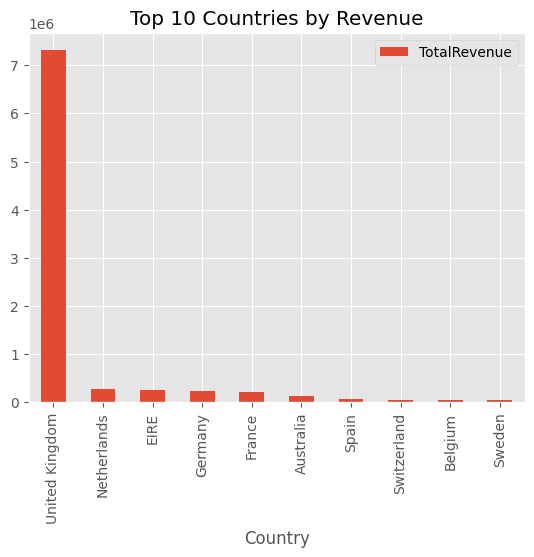

In [4]:
query_top_countries = """
SELECT 
    Country, 
    SUM(TotalLineItemAmount) as TotalRevenue
FROM dwd_ecommerce
GROUP BY Country
ORDER BY TotalRevenue DESC
LIMIT 10
"""
df_top_countries = pd.read_sql(query_top_countries, conn)

# 可视化
df_top_countries.plot(kind='bar', x='Country', y='TotalRevenue', title='Top 10 Countries by Revenue')
plt.show()

Text(0.5, 1.0, 'Monthly Sales Trend')

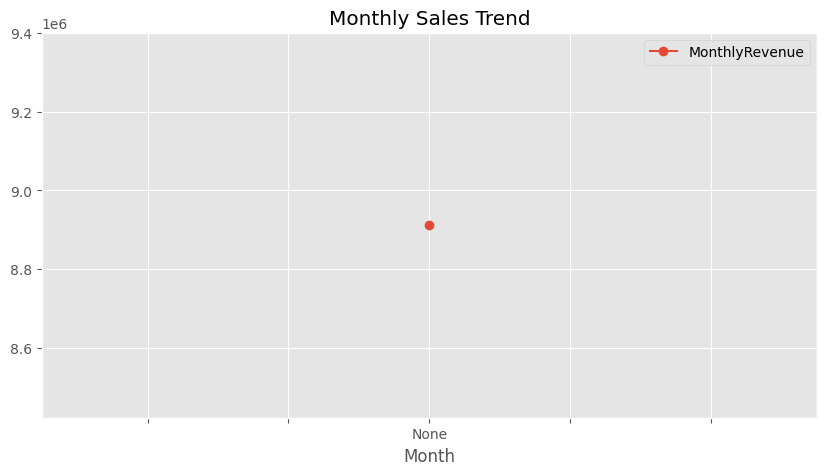

In [5]:
query_monthly = """
SELECT 
    strftime('%Y-%m', InvoiceDate) as Month,
    SUM(TotalLineItemAmount) as MonthlyRevenue
FROM dwd_ecommerce
GROUP BY Month
ORDER BY Month
"""
df_monthly = pd.read_sql(query_monthly, conn)
df_monthly.plot(x='Month', y='MonthlyRevenue', marker='o', figsize=(10, 5))
plt.title('Monthly Sales Trend')

Text(0.5, 1.0, 'Sales Volume by Hour of Day')

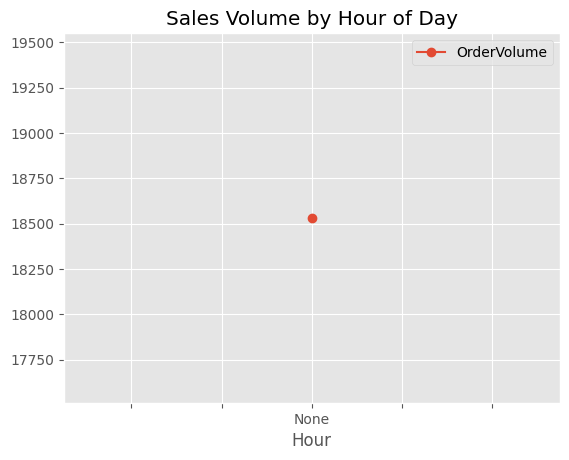

In [7]:
# 注意：SQLite strftime('%H', ...) 可以提取小时
query_hourly = """
SELECT 
    strftime('%H', InvoiceDate) as Hour,
    COUNT(DISTINCT InvoiceNo) as OrderVolume
FROM dwd_ecommerce
GROUP BY Hour
"""
df_hourly = pd.read_sql(query_hourly, conn)
df_hourly.plot(kind='line', x='Hour', y='OrderVolume', marker='o')
plt.title('Sales Volume by Hour of Day')

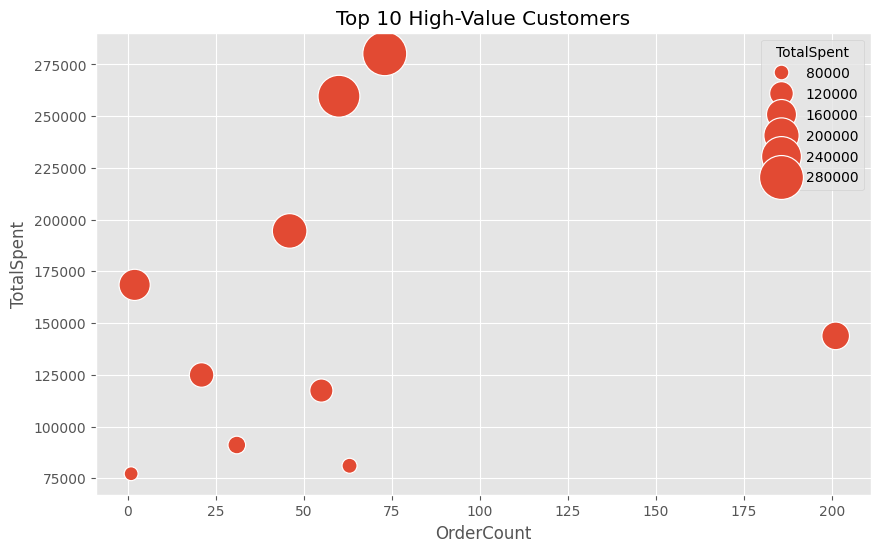

In [9]:
# Cell 6: Top 10 高价值客户分析
query_vip_customers = """
SELECT 
    CustomerID, 
    COUNT(DISTINCT InvoiceNo) as OrderCount, -- 购买次数
    SUM(TotalLineItemAmount) as TotalSpent   -- 消费总额
FROM dwd_ecommerce
GROUP BY CustomerID
ORDER BY TotalSpent DESC
LIMIT 10
"""
df_vip = pd.read_sql(query_vip_customers, conn)

# 绘制散点图查看消费习惯
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_vip, x='OrderCount', y='TotalSpent', size='TotalSpent', sizes=(100, 1000))
plt.title('Top 10 High-Value Customers')
plt.show()

In [ ]:
query_hot_products = """
SELECT 
    Description, 
    COUNT(DISTINCT InvoiceNo) as OrderCount
FROM dwd_ecommerce
GROUP BY Description
ORDER BY OrderCount DESC
LIMIT 20
"""
df_hot = pd.read_sql(query_hot_products, conn)
display(df_hot)

In [10]:
df_vip.to_sql('ads_top_customers', conn, if_exists='replace', index=False)
df_hourly.to_sql('ads_hourly_sales', conn, if_exists='replace', index=False)
print("Analysis results saved to ADS layer in database!")

Analysis results saved to ADS layer in database!


In [11]:
# 查看数据库中所有的表名（以及 ADS 表）
all_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
ads_tables = all_tables[all_tables["name"].str.startswith("ads_")].reset_index(drop=True)

display(all_tables)
print("\nADS tables:")
display(ads_tables)

,name
0,raw_ecommerce_data
1,ods_ecommerce
2,dwd_ecommerce
3,ads_top_customers
4,ads_hourly_sales


In [ ]:
# === Portfolio-ready dashboard (ADS) ===
# 先确保你已运行：
#   py scripts/load_data.py
#   py scripts/run_sql_analysis.py

import numpy as np

ads_gmv = pd.read_sql("SELECT * FROM ads_monthly_gmv_mom ORDER BY sale_month", conn)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(ads_gmv["sale_month"], ads_gmv["current_gmv"], marker="o")
ax1.set_title("GMV Trend (Monthly) + MoM Growth")
ax1.set_xlabel("Month")
ax1.set_ylabel("GMV")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(ads_gmv["sale_month"], ads_gmv["mom_growth_pct"], marker="o", linestyle="--", color="tab:orange")
ax2.set_ylabel("MoM Growth (%)")

plt.tight_layout()
plt.show()

In [ ]:
# RFM 分群：人数占比 & GMV 贡献
ads_rfm = pd.read_sql("SELECT * FROM ads_rfm_segments", conn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=ads_rfm, x="user_segment", y="user_pct", ax=axes[0])
axes[0].set_title("RFM Segments - User %")
axes[0].set_xlabel("")
axes[0].set_ylabel("User %")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=ads_rfm, x="user_segment", y="segment_gmv", ax=axes[1])
axes[1].set_title("RFM Segments - GMV")
axes[1].set_xlabel("")
axes[1].set_ylabel("GMV")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Cohort 留存热力图（retention_rate）
ads_ret = pd.read_sql("SELECT * FROM ads_cohort_retention", conn)

pivot = ads_ret.pivot(index="cohort_month", columns="month_offset", values="retention_rate").sort_index()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=False, cmap="Blues", linewidths=0.5)
plt.title("Cohort Retention Heatmap (%)")
plt.xlabel("Month Offset")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

In [ ]:
# 每月 Top3 商品（默认展示最新月份 Top3）
ads_top3 = pd.read_sql("SELECT * FROM ads_monthly_top3_products", conn)
latest_month = ads_top3["sale_month"].max()
df_latest = ads_top3[ads_top3["sale_month"] == latest_month].sort_values("rank_in_month")

plt.figure(figsize=(10, 4))
sns.barplot(data=df_latest, x="monthly_revenue", y="product_name")
plt.title(f"Top 3 Products by Revenue - {latest_month}")
plt.xlabel("Monthly Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()